# Custom CNN for Image Classification & Branch-Weighting Ablation (CIFAR-10, Fashion-MNIST)

**Asli Akel**

## Part 1: CIFAR-10 Image Classification


## 1. Setup and Imports

Relevant foundations: tensor processing, softmax classification, and multilayer perceptrons.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np

## 2. Device Setup

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## 3. CIFAR-10 Dataset and DataLoaders

The training dataset uses data augmentation to improve generalisation.  
The test dataset uses only normalisation.  
Normalisation values are the standard CIFAR-10 channel means and standard deviations.  
`num_workers=2` and `pin_memory=True` are added to speed up data loading, especially when using a GPU on Google Colab.

Relevant foundation: tensor and dataset processing.

In [ ]:
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    # Additional augmentation
    transforms.TrivialAugmentWide(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2470, 0.2435, 0.2616)
    ),
    # Random erasing augmentation
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.2))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2470, 0.2435, 0.2616)
    )
])

In [ ]:
train_dataset = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True, transform=train_transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=test_transform
)

In [ ]:
batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# Verify batch shape
images, labels = next(iter(train_loader))
print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

Image batch shape: torch.Size([128, 3, 32, 32])
Label batch shape: torch.Size([128])


## 4. Intermediate Block

Each intermediate block receives an input image $x$ and outputs a weighted combination of $L$ independent convolutional branches, where all branches operate on the same input $x$.

The weighting vector $\mathbf{a} = [a_1, \ldots, a_L]^T$ is produced by a fully connected layer using the channel-wise spatial average of $x$ (vector $\mathbf{m}$). The FC layer outputs are used directly without a softmax constraint, allowing the network to learn unconstrained branch weights.

Each branch contains two `Conv2d` layers together with Batch Normalisation and ReLU activations in order to increase feature extraction capacity. All convolutional layers preserve the spatial dimensions within the block.

The block uses `nn.Conv2d`, `nn.Linear`, and the standard `nn.Module` class structure.

In [ ]:
class IntermediateBlock(nn.Module):
    def __init__(self, in_channels, out_channels, num_convs, dropout=0.0):
        """
        Args:
            in_channels:  number of channels in the input image x
            out_channels: number of channels in each branch output (same for all)
            num_convs:    number of independent convolutional branches (L)
            dropout:      dropout probability applied after each branch
        """
        super().__init__()

        # L independent convolutional branches — each receives the same input x
        self.convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),
                # Second conv (confirmed enhancement): same spatial shape
                nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),
                nn.Dropout(dropout)
            )
            for _ in range(num_convs)
        ])

        # FC layer: channel-wise average -> weighting vector a (L units)
        self.fc = nn.Linear(in_channels, num_convs)
        # Near-zero init: keeps early weighted sum stable (prevents NaN)
        nn.init.normal_(self.fc.weight, mean=0.0, std=0.01)
        nn.init.zeros_(self.fc.bias)

        # Residual projection: align in_channels -> out_channels if needed
        # This allows a skip connection from x to the weighted output,
        self.residual = (
            nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
                nn.BatchNorm2d(out_channels)
            )
            if in_channels != out_channels
            else nn.Identity()
        )

    def forward(self, x):
        # Step 1: compute each branch output (all branches see the same x)
        conv_outputs = [conv(x) for conv in self.convs]

        # Step 2: channel-wise spatial average -> vector m, shape (B, in_channels)
        m = x.mean(dim=[2, 3])

        # Step 3: weighting vector a via FC layer (no softmax — raw output as per spec)
        a = self.fc(m)  # shape (B, num_convs)

        # Step 4: weighted combination x' = a1*C1(x) + ... + aL*CL(x)
        out = sum(a[:, i].view(-1, 1, 1, 1) * conv_outputs[i]
                  for i in range(len(self.convs)))

        # Step 5: residual skip connection — adds x (projected if needed) to output
        out = out + self.residual(x)

        return out  # shape: (B, out_channels, H, W)

In [ ]:
# Shape test
_test_block = IntermediateBlock(in_channels=3, out_channels=32, num_convs=2)
_sample = _test_block(images)
print("IntermediateBlock input shape: ", images.shape)   # (64, 3, 32, 32)
print("IntermediateBlock output shape:", _sample.shape)  # (64, 32, 32, 32)
del _test_block, _sample

IntermediateBlock input shape:  torch.Size([128, 3, 32, 32])
IntermediateBlock output shape: torch.Size([128, 32, 32, 32])


This confirms the block maps $3$ input channels to $32$ output channels while preserving the spatial dimensions ($32 \times 32$).

## 5. Output Block

The output block receives the feature map from the last intermediate block ($x$ with $c$ channels).  
It computes the channel-wise spatial average to form vector $\mathbf{m}$, then passes it through one or more fully connected layers to produce the logits vector $\mathbf{o}$.

The classifier produces one logit for each of the ten classes.

In [ ]:
class OutputBlock(nn.Module):
    def __init__(self, in_channels, hidden_dim=256, num_classes=10, dropout=0.3):
        """
        Args:
            in_channels: number of channels in the input feature map
            hidden_dim:  width of the intermediate FC layer
            num_classes: number of output classes (10 for CIFAR-10)
            dropout:     dropout probability between FC layers
        """
        super().__init__()

        self.classifier = nn.Sequential(
            # AdaptiveAvgPool2d(1,1) + Flatten is equivalent to x.mean(dim=[2,3])
            # but integrates cleanly into nn.Sequential
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(in_channels, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        return self.classifier(x)  # shape: (B, num_classes)

In [ ]:
# Shape test
_test_out = OutputBlock(in_channels=32, num_classes=10)
_placeholder = torch.randn(4, 32, 32, 32)
_logits = _test_out(_placeholder)
print("OutputBlock input shape: ", _placeholder.shape)  # (4, 32, 32, 32)
print("OutputBlock output shape:", _logits.shape)        # (4, 10)
del _test_out, _placeholder, _logits

OutputBlock input shape:  torch.Size([4, 32, 32, 32])
OutputBlock output shape: torch.Size([4, 10])


The output block correctly produces 10 class scores (logits) for each image in the batch.

## 6. Full Model

The full model stacks four intermediate blocks with increasing channel depth, separated by max-pooling to progressively reduce spatial dimensions:

$$32\times32 \xrightarrow{\text{pool}} 16\times16 \xrightarrow{\text{pool}} 8\times8 \xrightarrow{\text{pool}} 4\times4$$

The `OutputBlock` then averages channels spatially and produces 10 logits.  
The main branch-weighting structure is retained, while double-convolution branches, batch normalisation and dropout are added as modular extensions.

In [ ]:
class CustomCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.block1 = IntermediateBlock(3,   64,  num_convs=3, dropout=0.05)
        self.pool1  = nn.MaxPool2d(2)                         # 32x32 -> 16x16

        self.block2 = IntermediateBlock(64,  128, num_convs=3, dropout=0.10)
        self.pool2  = nn.MaxPool2d(2)                         # 16x16 -> 8x8

        self.block3 = IntermediateBlock(128, 256, num_convs=4, dropout=0.15)
        self.pool3  = nn.MaxPool2d(2)                         # 8x8  -> 4x4

        self.block4 = IntermediateBlock(256, 512, num_convs=4, dropout=0.20)

        self.output_block = OutputBlock(
            in_channels=512,
            hidden_dim=256,
            num_classes=10,
            dropout=0.3
        )

    def forward(self, x):
        x = self.pool1(self.block1(x))
        x = self.pool2(self.block2(x))
        x = self.pool3(self.block3(x))
        x = self.block4(x)
        x = self.output_block(x)
        return x

In [ ]:
# Architecture shape test
test_model = CustomCNN().to(device)
_out = test_model(images.to(device))
print("Model input shape: ", images.shape)  # (64, 3, 32, 32)
print("Model output shape:", _out.shape)    # (64, 10)
del test_model, _out

Model input shape:  torch.Size([128, 3, 32, 32])
Model output shape: torch.Size([128, 10])


The model correctly accepts a batch of $b \times 3 \times 32 \times 32$ images and outputs a $b \times 10$ logits matrix, as required by Section 1.3.

## 7. Loss Function, Optimiser, and Scheduler

- **`CrossEntropyLoss` with `label_smoothing=0.1`** — reduces overconfidence and improves generalisation.
- **SGD with momentum and weight decay** — strong baseline for CIFAR-10 training.
- **`CosineAnnealingLR`** — smoothly decays the learning rate over all epochs, encouraging fast early learning and stable final convergence.

`num_epochs = 40` with a 5-epoch linear warmup followed by cosine annealing. Nesterov momentum is used for slightly faster convergence. The best model weights are saved automatically during training.

These choices combine cross-entropy optimisation with gradient-based backpropagation.

In [ ]:
num_epochs    = 40
warmup_epochs = 5

model = CustomCNN().to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# Initial learning rate
optimizer = optim.SGD(
    model.parameters(),
    lr=0.1,
    momentum=0.9,
    weight_decay=5e-4,
    nesterov=True
)

# Cosine annealing after warmup
cosine_scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=num_epochs - warmup_epochs
)

# Linear warmup: start at lr/10, reach full lr after warmup_epochs
warmup_scheduler = optim.lr_scheduler.LinearLR(
    optimizer,
    start_factor=0.1,
    end_factor=1.0,
    total_iters=warmup_epochs
)

scheduler = optim.lr_scheduler.SequentialLR(
    optimizer,
    schedulers=[warmup_scheduler, cosine_scheduler],
    milestones=[warmup_epochs]
)

## 8. Accuracy Function

Evaluates the model on a given DataLoader by computing the fraction of correctly classified examples.  
`model.eval()` disables dropout and switches BatchNorm to use running statistics.

The calculation uses the predicted class with the highest output score.

In [ ]:
def calculate_accuracy(model, data_loader, device):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total   += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100.0 * correct / total

## 9. Training Loop

The model is trained for 40 epochs using minibatch SGD. After each epoch:
- `scheduler.step()` updates the learning rate
- Accuracy is evaluated on both the training and test datasets

Training accuracy may fluctuate between epochs due to stochastic data augmentation — each epoch the model sees slightly different versions of the training images.

The loop records loss and accuracy throughout training so that convergence can be examined afterwards.

In [ ]:
batch_losses     = []
train_accuracies = []
test_accuracies  = []
best_test_acc    = 0.0

batches_per_epoch = len(train_loader)
print_every = max(1, batches_per_epoch // 5)

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    nan_batches  = 0

    for batch_idx, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss    = criterion(outputs, labels)

        if torch.isnan(loss):
            nan_batches += 1
            continue

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        batch_losses.append(loss.item())
        running_loss += loss.item()

        if (batch_idx + 1) % print_every == 0:
            avg_so_far = running_loss / (batch_idx + 1 - nan_batches)
            print(f"  Epoch [{epoch+1}/{num_epochs}]  "
                  f"Batch [{batch_idx+1}/{batches_per_epoch}]  "
                  f"Loss: {avg_so_far:.4f}  "
                  f"LR: {optimizer.param_groups[0]['lr']:.5f}")

    scheduler.step()

    avg_loss  = running_loss / max(batches_per_epoch - nan_batches, 1)
    train_acc = calculate_accuracy(model, train_loader, device)
    test_acc  = calculate_accuracy(model, test_loader,  device)

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    if test_acc > best_test_acc:
        best_test_acc = test_acc
        torch.save(model.state_dict(), 'best_model.pth')

    nan_msg = f'  [!] {nan_batches} NaN batches skipped' if nan_batches else ''
    print(
        f'>>> Epoch [{epoch+1:2d}/{num_epochs}] DONE  '
        f'Loss: {avg_loss:.4f}  '
        f'Train: {train_acc:.2f}%  '
        f'Test: {test_acc:.2f}%  '
        f'Best: {best_test_acc:.2f}%'
        + nan_msg
    )

  Epoch [1/40]  Batch [78/391]  Loss: 2.1575  LR: 0.01000
  Epoch [1/40]  Batch [156/391]  Loss: 2.0883  LR: 0.01000
  Epoch [1/40]  Batch [234/391]  Loss: 2.0431  LR: 0.01000
  Epoch [1/40]  Batch [312/391]  Loss: 2.0029  LR: 0.01000
  Epoch [1/40]  Batch [390/391]  Loss: 1.9715  LR: 0.01000
>>> Epoch [ 1/40] DONE  Loss: 1.9712  Train: 38.43%  Test: 48.25%  Best: 48.25%
  Epoch [2/40]  Batch [78/391]  Loss: 1.8686  LR: 0.02800
  Epoch [2/40]  Batch [156/391]  Loss: 1.8563  LR: 0.02800
  Epoch [2/40]  Batch [234/391]  Loss: 1.8450  LR: 0.02800
  Epoch [2/40]  Batch [312/391]  Loss: 1.8266  LR: 0.02800
  Epoch [2/40]  Batch [390/391]  Loss: 1.8103  LR: 0.02800
>>> Epoch [ 2/40] DONE  Loss: 1.8102  Train: 42.83%  Test: 52.02%  Best: 52.02%
  Epoch [3/40]  Batch [78/391]  Loss: 1.7506  LR: 0.04600
  Epoch [3/40]  Batch [156/391]  Loss: 1.7436  LR: 0.04600
  Epoch [3/40]  Batch [234/391]  Loss: 1.7352  LR: 0.04600
  Epoch [3/40]  Batch [312/391]  Loss: 1.7152  LR: 0.04600
  Epoch [3/40]  B

## 10. Results

The highest test accuracy achieved was **93.36%** at epoch 40.  
Training accuracy fluctuates between epochs due to stochastic data augmentation — each epoch the model sees slightly different versions of the training images, which can cause temporary drops in measured training accuracy. The overall trend shows consistent improvement in generalisation throughout training.

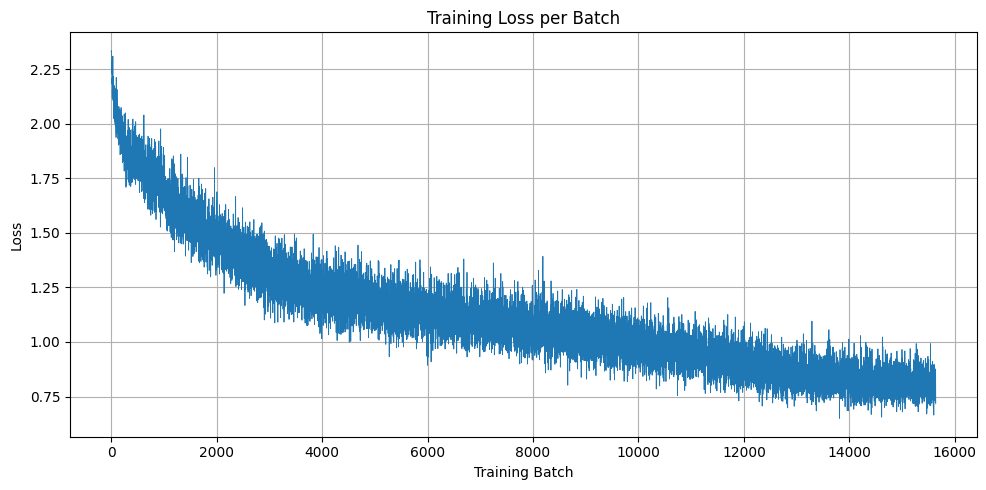

In [ ]:
# Plot 1: Training loss per batch
plt.figure(figsize=(10, 5))
plt.plot(batch_losses, linewidth=0.6)
plt.xlabel("Training Batch")
plt.ylabel("Loss")
plt.title("Training Loss per Batch")
plt.grid(True)
plt.tight_layout()
plt.show()

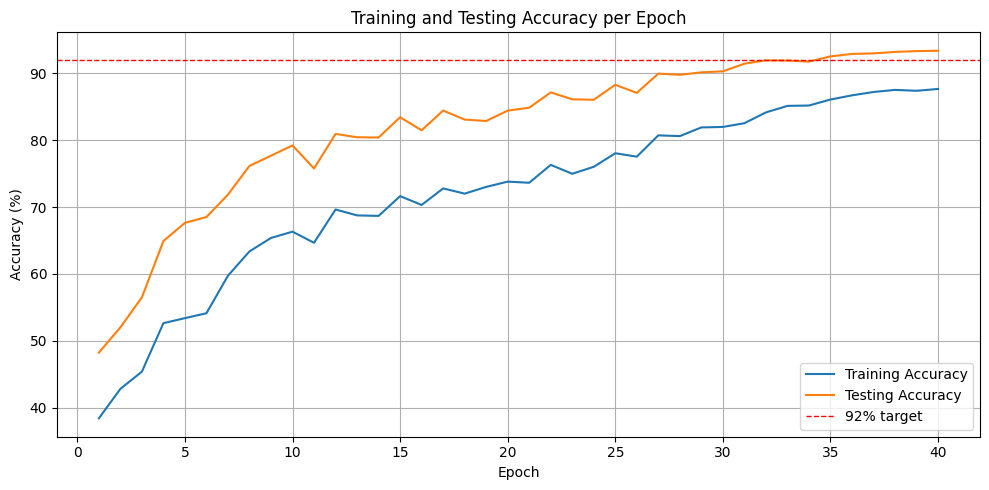

Best test accuracy (saved model): 93.36%
Peak test accuracy during training: 93.36%


In [ ]:
# Plot 2: Training and testing accuracy per epoch
epochs_range = range(1, len(train_accuracies) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs_range, train_accuracies, label='Training Accuracy')
plt.plot(epochs_range, test_accuracies,  label='Testing Accuracy')
plt.axhline(y=92, color='red', linestyle='--', linewidth=1, label='92% target')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training and Testing Accuracy per Epoch')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Load best model and report its accuracy
model.load_state_dict(torch.load('best_model.pth'))
final_best = calculate_accuracy(model, test_loader, device)
print(f'Best test accuracy (saved model): {final_best:.2f}%')
print(f'Peak test accuracy during training: {max(test_accuracies):.2f}%')